In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

##This cell imports the train_test_split function from Scikit-learn, which is used to divide the dataset into training and testing sets for machine learning model development.

In [3]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/DATA SET /cleaned_merged_dataset_v3.csv')

date_columns = [
    'booking_date',
    'ship_date',
    'expected_delivery_date',
    'actual_delivery_date',
    'registration_date',
    'forecast_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

#create target variable
df['shipment_delay'] = (
    df['actual_delivery_date'] -
    df['expected_delivery_date']
).dt.days

df['delay_days'] = df['shipment_delay'].clip(lower=0)

df['shipment_delayed'] = (
    df['shipment_delay'] > 0
).astype(int)

df[['shipment_delay', 'delay_days', 'shipment_delayed']].head()


,shipment_delay,delay_days,shipment_delayed
0,3,3,1
1,1,1,1
2,0,0,0
3,3,3,1
4,0,0,0


##Interpretation

Shipment delay is calculated using the difference between the actual and expected delivery dates. A binary target variable named shipment_delayed is created, where 0 represents on-time delivery and 1 represents delayed delivery.

In [6]:
# Booking Date Features
df['booking_year'] = df['booking_date'].dt.year
df['booking_month'] = df['booking_date'].dt.month
df['booking_day'] = df['booking_date'].dt.day
df['booking_weekday'] = df['booking_date'].dt.dayofweek

# Ship Date Features
df['ship_year'] = df['ship_date'].dt.year
df['ship_month'] = df['ship_date'].dt.month
df['ship_day'] = df['ship_date'].dt.day
df['ship_weekday'] = df['ship_date'].dt.dayofweek

# Expected Delivery Features
df['expected_year'] = df['expected_delivery_date'].dt.year
df['expected_month'] = df['expected_delivery_date'].dt.month
df['expected_day'] = df['expected_delivery_date'].dt.day
df['expected_weekday'] = df['expected_delivery_date'].dt.dayofweek

# Registration Features
df['registration_year'] = df['registration_date'].dt.year

# Forecast Features
df['forecast_month'] = df['forecast_date'].dt.month
df['forecast_weekday'] = df['forecast_date'].dt.dayofweek

print("Feature Engineering Completed Successfully")

Feature Engineering Completed Successfully


##Interpretation

Date-related attributes are transformed into meaningful numerical features such as year, month, day, and weekday. These engineered features help the machine learning model identify seasonal trends, weekly shipment patterns, and other time-based relationships that influence shipment delays.

In [7]:
print("Total Missing Values :", df.isnull().sum().sum())

Total Missing Values : 0


In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [9]:
print("Target Variable Distribution\n")

print(df['shipment_delayed'].value_counts())

print("\nPercentage Distribution\n")

print(
    round(
        df['shipment_delayed']
        .value_counts(normalize=True)*100,
        2
    )
)

Target Variable Distribution

shipment_delayed
0    2546
1    1474
Name: count, dtype: int64

Percentage Distribution

shipment_delayed
0    63.33
1    36.67
Name: proportion, dtype: float64


##Interpretation

The target variable is verified to ensure that it contains valid classes representing on-time and delayed shipments. The percentage distribution also helps identify whether the dataset is balanced.

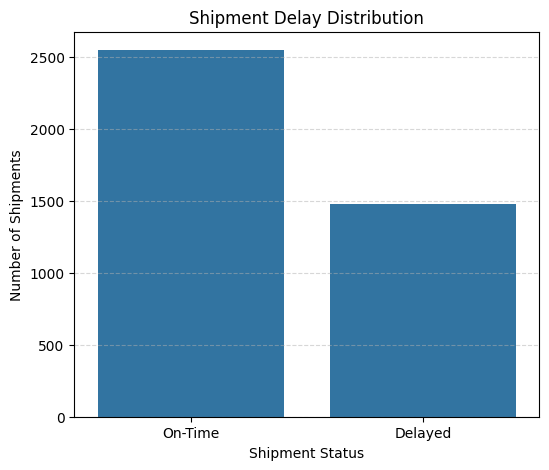

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='shipment_delayed'
)

plt.title("Shipment Delay Distribution")

plt.xlabel("Shipment Status")

plt.ylabel("Number of Shipments")

plt.xticks(
    [0,1],
    ["On-Time","Delayed"]
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

##Interpretation

The class distribution is visualized using a count plot. This helps determine whether the number of delayed shipments is significantly different from the number of on-time shipments.

In [11]:
free_text_columns = [
    'customer_name',
    'carrier_name',
    'supplier_name',
    'product_name',
    'origin_city',
    'destination_city',
    'origin_port',
    'destination_port',
    'vehicle_number',
    'warehouse_name'
]

df.drop(
    columns=free_text_columns,
    errors='ignore',
    inplace=True
)

print("Free Text Columns Removed Successfully")

Free Text Columns Removed Successfully


##Interpretation

Free-text columns are removed because they contain descriptive information that cannot be directly processed by most machine learning algorithms.

In [12]:
label_encoder = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("Categorical Features Encoded Successfully")

print("\nRemaining Object Columns")

print(df.select_dtypes(include='object').columns)

Categorical Features Encoded Successfully

Remaining Object Columns
Index([], dtype='object')


##Interpretation

All categorical variables are converted into numerical values using Label Encoding. This transformation allows machine learning algorithms to process categorical information efficiently.

In [13]:
# Remove unnecessary columns

drop_columns = [

    # Target
    'shipment_delayed',

    # Target Leakage
    'shipment_delay',
    'delay_days',
    'actual_delivery_date',

    # ID Columns
    'shipment_id',
    'booking_id',
    'customer_id',
    'product_id',
    'carrier_id',
    'warehouse_id',
    'route_id',
    'vehicle_id',
    'customs_id',
    'weather_id',
    'history_id',

    # Original Date Columns
    'booking_date',
    'ship_date',
    'expected_delivery_date',
    'registration_date',
    'forecast_date'
]

X = df.drop(columns=drop_columns)

y = df['shipment_delayed']

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (4020, 71)
Target Shape : (4020,)


##Interpretation

The dataset is divided into the feature matrix (X) and the target variable (y). Identifier columns, original date columns, and target leakage variables are removed because they do not contribute to prediction or may provide information that would unfairly influence the model. The remaining engineered features are retained for machine learning.

In [14]:
print("Feature Data Types\n")

print(X.dtypes.value_counts())

print("\nRemaining Object Columns")

print(X.select_dtypes(include='object').columns)

print("\nRemaining Datetime Columns")

print(X.select_dtypes(include='datetime64[ns]').columns)

Feature Data Types

int64      30
float64    17
int32      15
bool        9
Name: count, dtype: int64

Remaining Object Columns
Index([], dtype='object')

Remaining Datetime Columns
Index([], dtype='object')


##Interpretation

The feature matrix is verified to ensure that all input variables are numerical. No object-type or datetime columns remain, confirming that the dataset is fully prepared for train-test splitting and machine learning model development.

In [15]:
print("="*80)

print("Final Features Selected for Model Training")

print("="*80)

for i, col in enumerate(X.columns, start=1):
    print(f"{i}. {col}")

print("\nTotal Features :", len(X.columns))

Final Features Selected for Model Training
1. shipping_mode
2. shipment_type
3. priority
4. weight_kg
5. volume_cbm
6. declared_value
7. insurance
8. fragile_x
9. carrier_type
10. average_rating
11. fleet_size
12. years_of_service
13. headquarters
14. customer_type
15. industry
16. city_x
17. state_x
18. country
19. customer_status
20. customs_required
21. documentation_complete
22. inspection_required
23. cargo_type
24. destination_country_x
25. category
26. hs_code
27. hazardous
28. perishable
29. temperature_controlled
30. fragile_y
31. weight_per_unit
32. origin_country
33. destination_country_y
34. distance_km
35. average_transit_days
36. route_risk
37. traffic_index
38. delivery_status
39. delivery_attempts
40. vehicle_type
41. capacity_kg
42. fuel_type
43. maintenance_status
44. vehicle_age
45. city_y
46. state_y
47. warehouse_capacity
48. current_utilization
49. warehouse_type
50. city
51. weather_condition
52. temperature
53. rainfall
54. humidity
55. wind_speed
56. visibility

##Interpretation

The final feature list is displayed to document all the variables selected for machine learning model development. Only relevant predictive features are retained after removing identifier columns, target leakage variables, original datetime columns, and free-text attributes.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Dataset Split Successfully")

Dataset Split Successfully


##Interpretation

The dataset is divided into two subsets using an 80:20 ratio. The training dataset (80%) will be used to train the machine learning model, while the testing dataset (20%) will be used to evaluate its performance on unseen data. The random_state=42 parameter ensures reproducibility, and stratify=y preserves the original class distribution in both datasets.

In [17]:
print("Training Feature Matrix :", X_train.shape)

print("Testing Feature Matrix :", X_test.shape)

print()

print("Training Target :", y_train.shape)

print("Testing Target :", y_test.shape)

print()

print("Training Percentage :",
      round(len(X_train)/len(X)*100,2),"%")

print("Testing Percentage :",
      round(len(X_test)/len(X)*100,2),"%")

Training Feature Matrix : (3216, 71)
Testing Feature Matrix : (804, 71)

Training Target : (3216,)
Testing Target : (804,)

Training Percentage : 80.0 %
Testing Percentage : 20.0 %


##Interpretation

The dataset split is verified by checking the dimensions of the training and testing datasets. Approximately 80% of the observations are allocated for training, while the remaining 20% are reserved for testing.

In [18]:
print("Training Dataset Class Distribution\n")

print(y_train.value_counts())

print("\nPercentage Distribution\n")

print(
    round(
        y_train.value_counts(normalize=True)*100,
        2
    )
)

Training Dataset Class Distribution

shipment_delayed
0    2037
1    1179
Name: count, dtype: int64

Percentage Distribution

shipment_delayed
0    63.34
1    36.66
Name: proportion, dtype: float64


##Interpretation

The class distribution of the training dataset is verified to ensure that both delayed and on-time shipment classes are proportionally represented after dataset splitting.

In [19]:
print("Testing Dataset Class Distribution\n")

print(y_test.value_counts())

print("\nPercentage Distribution\n")

print(
    round(
        y_test.value_counts(normalize=True)*100,
        2
    )
)

Testing Dataset Class Distribution

shipment_delayed
0    509
1    295
Name: count, dtype: int64

Percentage Distribution

shipment_delayed
0    63.31
1    36.69
Name: proportion, dtype: float64


##Interpretation

The testing dataset is examined to confirm that the class distribution remains similar to the original dataset, ensuring a fair evaluation of the machine learning model.

/tmp/ipykernel_847/364246071.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


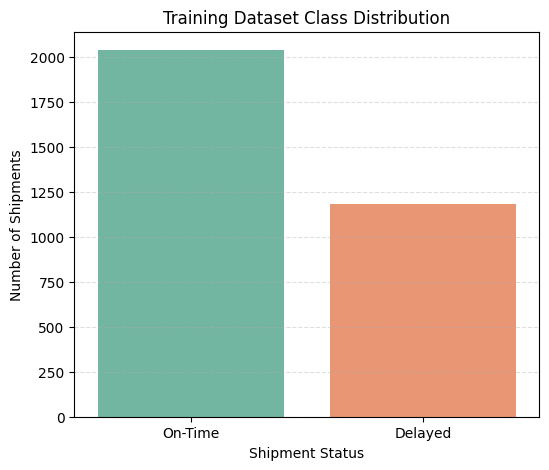

In [20]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=y_train,
    palette="Set2"
)

plt.title("Training Dataset Class Distribution")

plt.xlabel("Shipment Status")

plt.ylabel("Number of Shipments")

plt.xticks(
    [0,1],
    ["On-Time","Delayed"]
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

##Interpretation

The count plot shows the distribution of delayed and on-time shipments in the training dataset. It confirms that both classes are adequately represented for model learning.

/tmp/ipykernel_847/1209648787.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


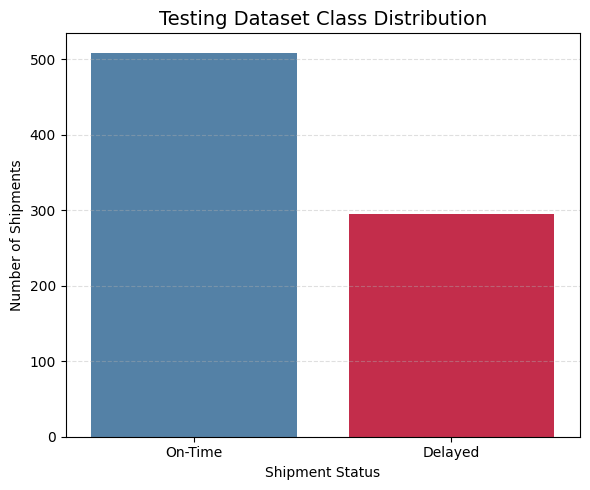

In [25]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x=y_test,
    palette=['steelblue', 'crimson']
)

plt.title("Testing Dataset Class Distribution", fontsize=14)

plt.xlabel("Shipment Status")

plt.ylabel("Number of Shipments")

plt.xticks(
    [0,1],
    ["On-Time","Delayed"]
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

##Interpretation

The testing dataset class distribution is visualized to verify that the delayed and on-time shipment proportions remain consistent after dataset splitting.

In [28]:
comparison = pd.DataFrame({

    "Original (%)":
    round(
        y.value_counts(normalize=True)*100,
        2
    ),

    "Training (%)":
    round(
        y_train.value_counts(normalize=True)*100,
        2
    ),

    "Testing (%)":
    round(
        y_test.value_counts(normalize=True)*100,
        2
    )

})

comparison

,Original (%),Training (%),Testing (%)
shipment_delayed,,,
0,63.33,63.34,63.31
1,36.67,36.66,36.69


##Interpretation

The class distribution of the original, training, and testing datasets is compared to verify that stratified sampling has preserved the same proportion of delayed and on-time shipments across all datasets. This ensures that the model will be trained and evaluated on representative data.

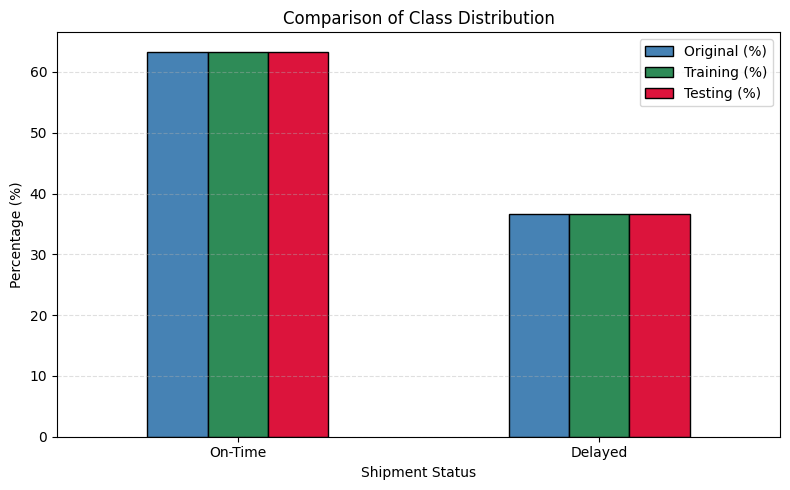

In [30]:
comparison.plot(
    kind='bar',
    figsize=(8,5),
    color=['steelblue','seagreen','crimson'],
    edgecolor='black'
)

plt.title("Comparison of Class Distribution")

plt.xlabel("Shipment Status")

plt.ylabel("Percentage (%)")

plt.xticks(
    [0,1],
    ["On-Time","Delayed"],
    rotation=0
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.legend(loc='upper right')

plt.tight_layout()

plt.show()

##Interpretation

The grouped bar chart visually compares the class distribution across the original, training, and testing datasets. Similar percentages indicate that stratified sampling has successfully maintained the original class balance.

In [31]:
print("="*70)

print("Why random_state = 42 ?")

print("="*70)

print("""
1. Ensures reproducibility of the experiment.

2. Produces the same train-test split every time the notebook is executed.

3. Makes model comparison fair and consistent.

4. Helps other researchers reproduce the same results.
""")

Why random_state = 42 ?

1. Ensures reproducibility of the experiment.

2. Produces the same train-test split every time the notebook is executed.

3. Makes model comparison fair and consistent.

4. Helps other researchers reproduce the same results.



##Interpretation

The random_state=42 parameter ensures that the dataset is split consistently every time the notebook is executed. This improves reproducibility and allows fair comparison between different machine learning models.

In [32]:
print("="*70)

print("Why stratify = y ?")

print("="*70)

print("""
1. Preserves the original class distribution.

2. Maintains the ratio of delayed and on-time shipments.

3. Prevents class imbalance after dataset splitting.

4. Improves the reliability of classification model evaluation.
""")

Why stratify = y ?

1. Preserves the original class distribution.

2. Maintains the ratio of delayed and on-time shipments.

3. Prevents class imbalance after dataset splitting.

4. Improves the reliability of classification model evaluation.



##Interpretation

Stratified sampling ensures that both the training and testing datasets contain approximately the same proportion of delayed and on-time shipments as the original dataset, resulting in more reliable model training and evaluation.

In [33]:
print("="*80)

print("Task 2 - Dataset Splitting Completed Successfully")

print("="*80)

print("\nOriginal Dataset Shape :", X.shape)

print("Training Feature Matrix :", X_train.shape)

print("Testing Feature Matrix :", X_test.shape)

print()

print("Training Target :", y_train.shape)

print("Testing Target :", y_test.shape)

print()

print("Split Ratio : 80% Training | 20% Testing")

print("Random State : 42")

print("Stratified Sampling : Applied")

print()

print("Training Missing Values :", X_train.isnull().sum().sum())

print("Testing Missing Values :", X_test.isnull().sum().sum())

print()

print("Remaining Object Columns :", len(X.select_dtypes(include='object').columns))

print("Remaining Datetime Columns :", len(X.select_dtypes(include=['datetime64[ns]']).columns))

print()

print("The dataset has been successfully prepared and split into training and testing datasets.")

print("It is now ready for building the baseline Logistic Regression model.")

Task 2 - Dataset Splitting Completed Successfully

Original Dataset Shape : (4020, 71)
Training Feature Matrix : (3216, 71)
Testing Feature Matrix : (804, 71)

Training Target : (3216,)
Testing Target : (804,)

Split Ratio : 80% Training | 20% Testing
Random State : 42
Stratified Sampling : Applied

Training Missing Values : 0
Testing Missing Values : 0

Remaining Object Columns : 0
Remaining Datetime Columns : 0

The dataset has been successfully prepared and split into training and testing datasets.
It is now ready for building the baseline Logistic Regression model.


##Interpretation

The final summary confirms that the dataset has been successfully split into training and testing sets using an 80:20 ratio. The preprocessing steps have been completed, no object or datetime columns remain, and the data is now fully prepared for building the baseline Logistic Regression model.